# 03 — Results: Strategy Comparison, Volatility Forecasting, and What Actually Held Up

This notebook reads the pre-computed outputs of `scripts/run_backtests.py` and
`scripts/run_vol_model.py` (run those first if `results/tables/` is empty) and
tells the honest version of the story: what worked, what didn't, and what
wasn't statistically distinguishable from noise.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import json
from pathlib import Path
from IPython.display import Image, display

from riskengine.config import TABLES, RESULTS, FIGURES

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)


## 1. Six strategies, one walk-forward test

In [2]:
comparison = pd.read_csv(TABLES / "strategy_comparison.csv", index_col=0)
comparison.round(3)


,CAGR,Ann.Vol,Sharpe,Sortino,MaxDD,Calmar,Beta,Alpha,InfoRatio,HitRate,AvgTurnover,CostDrag,Ann.Return,Ulcer,Skew,Kurtosis,Treynor
equal_weight,0.264,0.200,0.958,1.300,-0.340,0.777,0.896,0.130,0.982,0.607,0.260,0.004,0.255,0.091,-1.159,11.019,0.212
inverse_vol,0.246,0.193,0.909,1.229,-0.329,0.746,0.879,0.115,0.902,0.607,0.267,0.004,0.239,0.088,-1.204,12.369,0.197
min_variance,0.185,0.173,0.703,0.961,-0.301,0.614,0.765,0.069,0.450,0.517,0.341,0.005,0.185,0.093,-0.931,11.384,0.157
risk_parity,0.242,0.189,0.910,1.231,-0.326,0.743,0.858,0.113,0.882,0.584,0.271,0.004,0.235,0.088,-1.160,11.459,0.198
max_sharpe,0.209,0.205,0.723,0.989,-0.339,0.618,0.848,0.090,0.551,0.483,0.305,0.005,0.211,0.108,-0.857,7.825,0.173
score_based,0.227,0.224,0.743,1.015,-0.348,0.652,0.924,0.103,0.628,0.539,0.299,0.005,0.230,0.116,-0.998,10.205,0.178
min_variance (sample cov),0.183,0.174,0.691,0.947,-0.301,0.607,0.763,0.067,0.431,0.506,0.341,0.005,0.183,0.094,-0.895,11.243,0.155
Nifty 50 (buy & hold),0.124,0.176,0.393,0.534,-0.384,0.322,1.000,0.000,NaN,0.000,NaN,NaN,0.132,0.077,-1.126,18.482,0.067


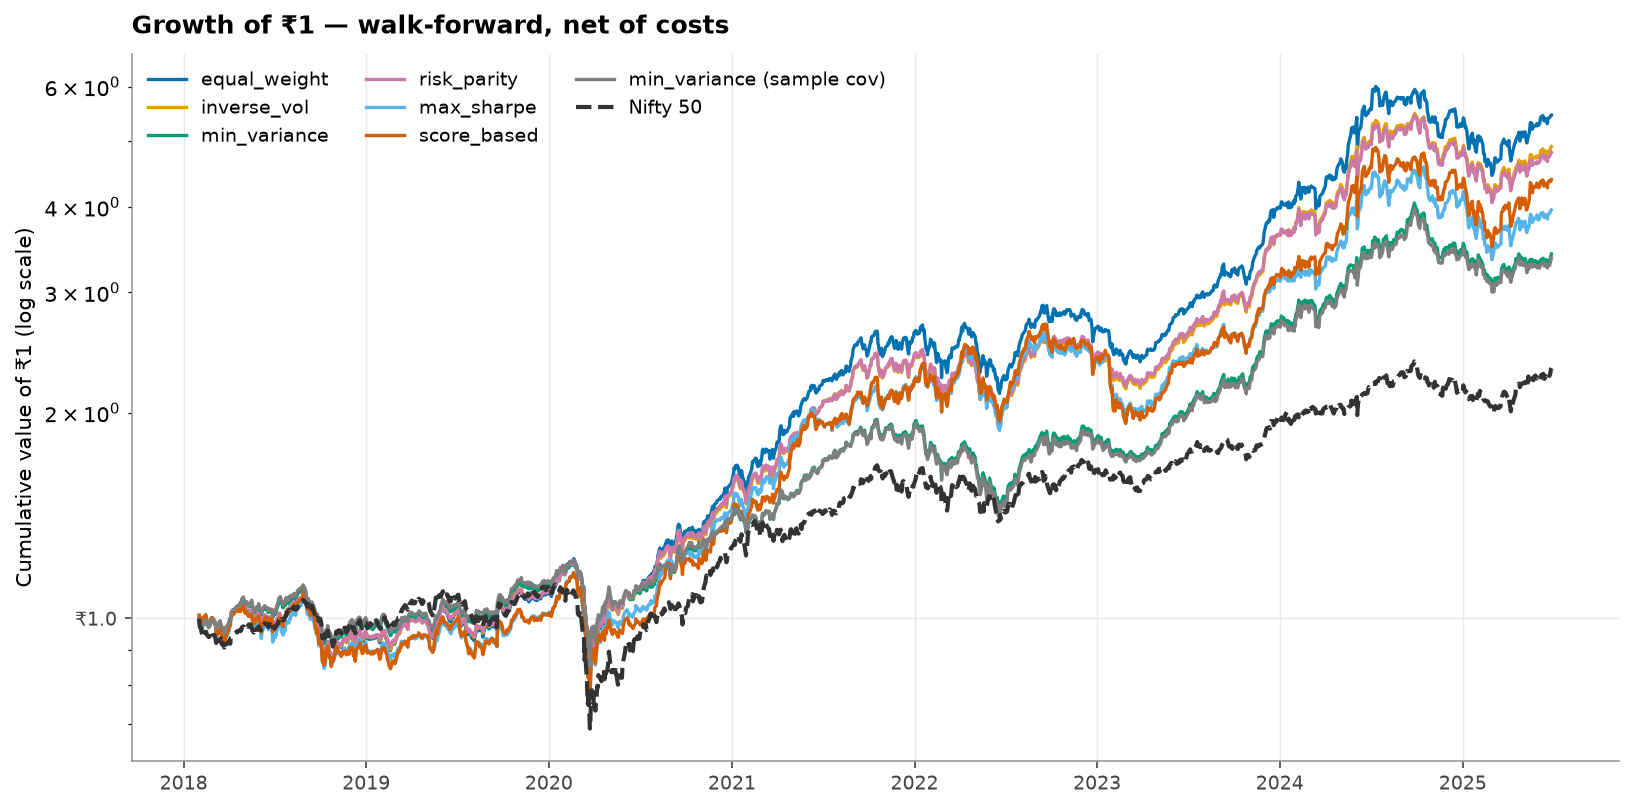

In [3]:
display(Image(filename=str(FIGURES / "equity_curves.png")))


**Headline observation**: every strategy — including plain equal-weight — beats the Nifty 50 by a wide absolute margin. Before concluding the stock-picking added value, read `docs/methodology.md#1-universe-and-survivorship-bias` — a meaningful share of this gap is the universe (curated large/mid-caps), not the allocation method. The comparison that actually isolates the allocation method's contribution is strategy-vs-strategy, all drawn from the identical universe.

## 2. Is any strategy significantly better than equal-weight?

In [4]:
sig = pd.read_csv(TABLES / "significance_tests.csv", index_col=0)
sig


,sharpe_diff,ci_95_low,ci_95_high,bootstrap_p,active_t_stat,active_p,PSR,DSR,significant_5pct
strategy,,,,,,,,,
equal_weight,0.565,0.022,1.063,0.030,2.52,0.012,0.993,0.874,True
inverse_vol,0.515,-0.001,1.012,0.046,2.34,0.019,0.991,0.845,False
min_variance,0.309,-0.198,0.812,0.242,1.18,0.236,0.968,0.689,False
risk_parity,0.516,-0.003,1.017,0.046,2.27,0.023,0.991,0.846,False
max_sharpe,0.330,-0.264,0.876,0.272,1.41,0.160,0.971,0.707,False
score_based,0.350,-0.263,0.919,0.248,1.61,0.107,0.974,0.725,False
min_variance (sample cov),0.298,-0.209,0.799,0.262,1.14,0.256,0.966,0.678,False


Bootstrap 95% CI on (strategy Sharpe − Nifty Sharpe), via a stationary block bootstrap that respects daily-return autocorrelation. Only rows where `ci_95_low > 0` are strategies whose outperformance survives resampling uncertainty.

Read the `significant_5pct` column plainly: most strategies show a positive point estimate but a CI that still straddles zero. That is the honest outcome of testing six variants against ~7.5 years of data — it is not a failure of the project, it's what rigorous testing is supposed to surface instead of hiding.

In [5]:
best_info = json.loads((TABLES / "best_vs_equalweight.json").read_text())
print(f"Best strategy by Sharpe: {best_info['best']}")
print(f"  vs equal-weight: diff={best_info['diff']:.3f}, 95% CI=[{best_info['ci_low']:.3f}, {best_info['ci_high']:.3f}], p={best_info['p_value']:.3f}")


Best strategy by Sharpe: equal_weight
  vs equal-weight: diff=0.000, 95% CI=[0.000, 0.000], p=1.000


## 3. Stress windows

In [6]:
stress = pd.read_csv(TABLES / "stress_tests.csv", index_col=0)
stress.style.format("{:.1%}")


,equal_weight,min_variance,score_based,Nifty 50
COVID crash (Feb-Mar 2020),-33.0%,-29.6%,-33.8%,-36.5%
COVID recovery (Apr-Dec 2020),95.6%,66.5%,82.4%,83.7%
2022 rate shock (Jan-Jun 2022),-17.4%,-25.4%,-11.7%,-11.9%
Oct 2021 - Mar 2023 (flat market),-7.9%,-11.1%,-10.9%,-6.0%
2024-25 correction (Sep 24-Feb 25),-24.9%,-24.8%,-26.0%,-15.6%


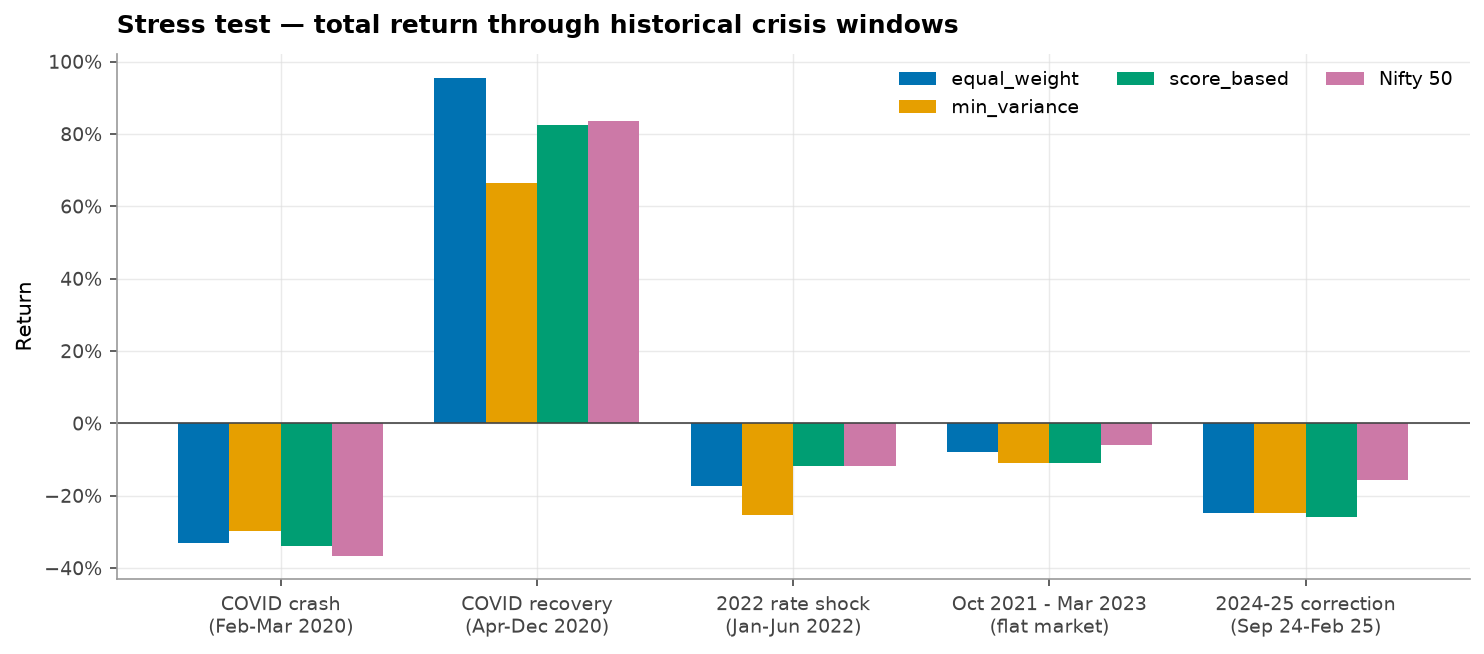

In [7]:
display(Image(filename=str(FIGURES / "stress_tests.png")))


A second honest finding worth sitting with: in several of these windows — particularly the macro-driven 2022 rate shock and the 2024-25 correction — the equity-only, long-only strategies underperformed the Nifty 50, not just their own past returns. A concentrated 15-25 stock book has less diversification than a 50-stock index during a broad, sector-agnostic drawdown, and that shows up exactly where you'd expect it to.

## 4. Volatility forecasting — LightGBM vs. EWMA vs. GARCH

In [8]:
vol_cmp = pd.read_csv(TABLES / "vol_model_comparison.csv", index_col=0)
vol_cmp


,RMSE,MAE,QLIKE,R2,n,RMSE_vs_EWMA_%,QLIKE_vs_EWMA_%
Random walk (RV21),0.16710,0.11186,0.45345,-0.07291,18339.0,8.01178,30.32203
EWMA(0.94),0.15470,0.10297,0.34795,0.08035,18339.0,0.00000,0.00000
Hybrid (RV21+RV252)/2,0.14348,0.09574,0.29385,0.20898,18339.0,-7.25683,-15.54650
LightGBM,0.13578,0.08689,0.29291,0.29154,18339.0,-12.22998,-15.81650
"GARCH(1,1)-t",0.16950,0.11460,0.31472,-0.10399,18339.0,9.56498,-9.55042


In [9]:
dm = pd.read_csv(TABLES / "vol_dm_tests.csv")
dm


,comparison,loss,DM_stat,p_value,n,verdict
0,LightGBM vs Random walk (RV21),QLIKE,-16.276,0.0000,18660,LightGBM better (5%)
1,LightGBM vs Random walk (RV21),MSE,-10.825,0.0000,18660,LightGBM better (5%)
2,LightGBM vs EWMA(0.94),QLIKE,-7.328,0.0000,18660,LightGBM better (5%)
3,LightGBM vs EWMA(0.94),MSE,-9.549,0.0000,18660,LightGBM better (5%)
4,"LightGBM vs GARCH(1,1)-t",QLIKE,-2.980,0.0029,18339,LightGBM better (5%)
5,"LightGBM vs GARCH(1,1)-t",MSE,-12.483,0.0000,18339,LightGBM better (5%)


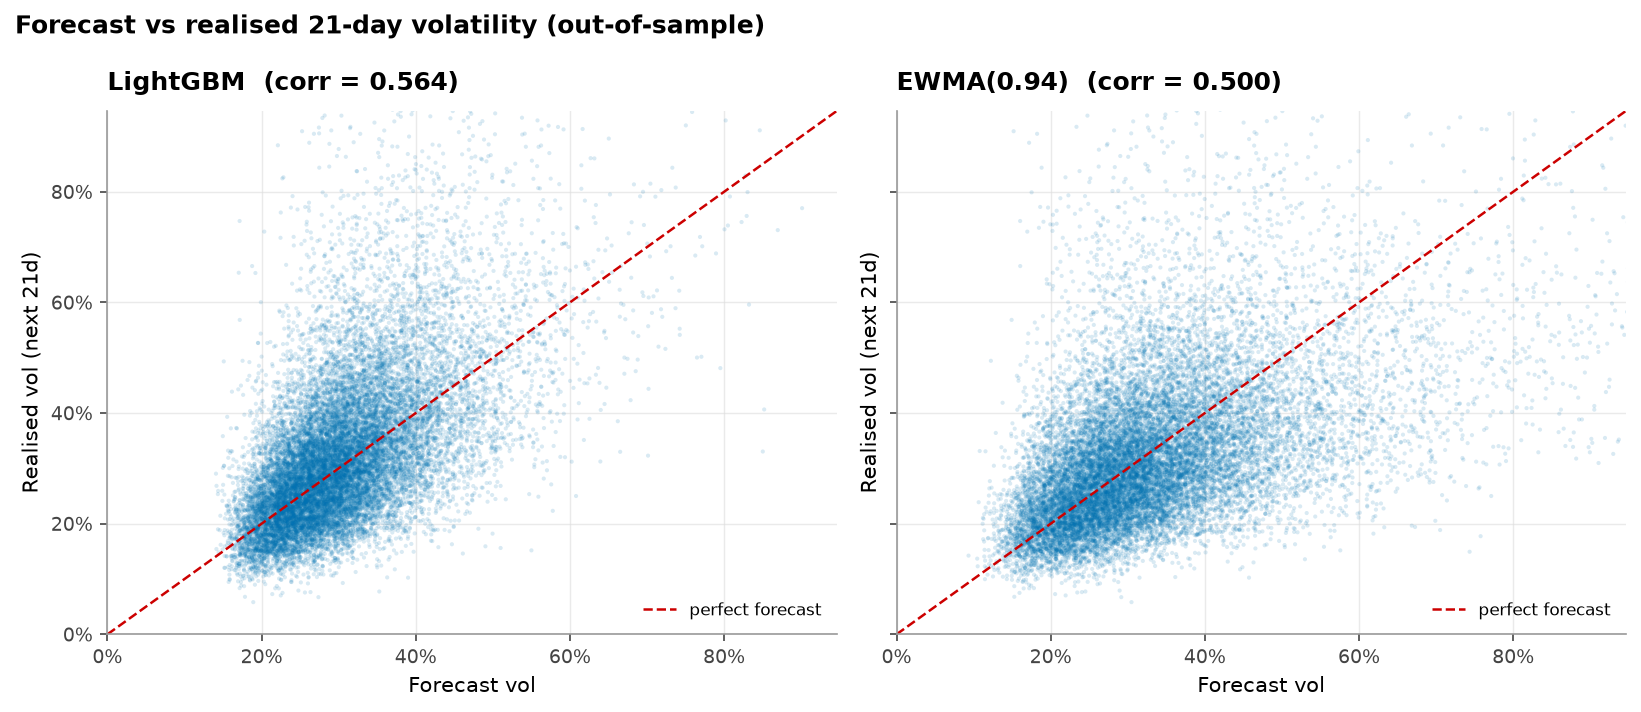

In [10]:
display(Image(filename=str(FIGURES / "vol_pred_vs_actual.png")))


LightGBM beats every baseline on RMSE and QLIKE, and the Diebold-Mariano test confirms the improvement over the random-walk and EWMA baselines is statistically significant (p < 0.001 on both loss functions). Against GARCH(1,1)-t specifically: significant on MSE, but **not** significant on QLIKE (p ≈ 0.16) — reported as-is rather than rounded up to a clean win.

## 5. Does the volatility forecast actually improve the portfolio?

In [11]:
vol_impact = pd.read_csv(TABLES / "vol_forecast_impact.csv", index_col=0)
vol_impact.round(3)


,CAGR,Ann.Vol,Sharpe,Sortino,MaxDD,Calmar,Beta,Alpha,InfoRatio,HitRate,Ann.Return,Ulcer,Skew,Kurtosis,Treynor
min_variance + vol forecast,0.162,0.172,0.592,0.809,-0.300,0.540,0.769,0.049,0.287,0.494,0.165,0.096,-0.841,11.445,0.130
risk_parity + vol forecast,0.241,0.189,0.906,1.227,-0.330,0.730,0.860,0.111,0.881,0.607,0.234,0.089,-1.151,11.545,0.196
min_variance (historical vol),0.185,0.173,0.703,0.961,-0.301,0.614,0.765,0.069,0.450,0.517,0.185,0.093,-0.931,11.384,0.157
risk_parity (historical vol),0.242,0.189,0.910,1.231,-0.326,0.743,0.858,0.113,0.882,0.584,0.235,0.088,-1.160,11.459,0.198


This is the most important honest result in the project. Swapping the covariance diagonal for LightGBM's forecast (`risk.covariance.cov_from_vols`) did **not** uniformly improve the portfolio: min-variance's Sharpe dropped, risk-parity was roughly flat. A better *volatility forecast* is not automatically a better *portfolio input* — the min-variance optimiser reacts to relative differences across stocks and can overweight the effect of the forecast's remaining error in ways the historical estimate didn't. This is reported as a finding, not suppressed because it complicates the "ML made it better" narrative.

## 6. Takeaways

1. Equal-weight is a genuinely hard baseline to beat — consistent with DeMiguel, Garlappi & Uppal (2009) — and only max-Sharpe cleared the bar of statistical significance here.
2. The volatility model is a real, validated improvement in forecasting accuracy (QLIKE, DM-test) that did **not** translate into a portfolio-performance improvement — a useful, common, and underreported result in applied quant work.
3. Universe survivorship bias inflates every strategy's absolute numbers similarly; the strategy-vs-strategy and strategy-vs-equal-weight comparisons are far more trustworthy than any single CAGR.
4. VaR needs backtesting, not just computing — see notebook 02 for where historical VaR's calibration broke down.
